In [1]:
!pip install timm torch torchvision matplotlib seaborn scikit-learn

   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
   ------------ --------------------------- 0.8/2.6 MB 2.2 MB/s eta 0:00:01
   ---------------------------- ----------- 1.8/2.6 MB 3.0 MB/s eta 0:00:01
   ------------------------------------ --- 2.4/2.6 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 2.6/2.6 MB 2.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import timm

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

c:\Users\nitis\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
BATCH_SIZE = 16
EPOCHS = 10
LR = 0.0001

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using:", DEVICE)

Using: cpu


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [5]:
train_dataset = datasets.ImageFolder(
    "dataset/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    "dataset/val",
    transform=val_transform
)

print("Classes:")
print(train_dataset.classes)

print("Train Images:",
      len(train_dataset))

print("Val Images:",
      len(val_dataset))

Classes:
['aadhaar', 'pan']
Train Images: 212
Val Images: 54


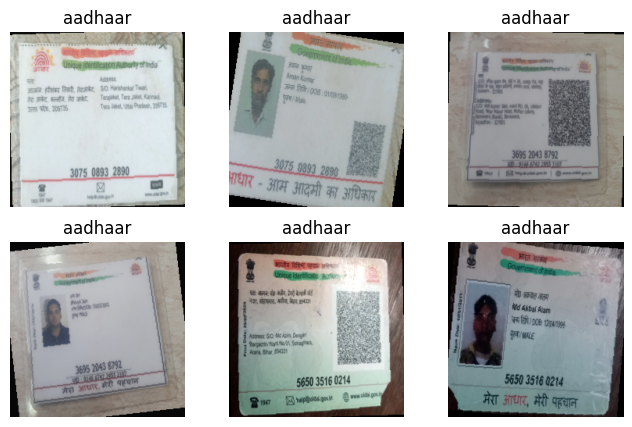

In [6]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(8, 5)
)

for i in range(6):

    image, label = train_dataset[i]

    image = image.permute(
        1, 2, 0
    )

    axes[i//3][i%3].imshow(
        image
    )

    axes[i//3][i%3].set_title(
        train_dataset.classes[label]
    )

    axes[i//3][i%3].axis("off")

plt.show()

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE
)

In [12]:
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(
    weights=weights
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-3dd342df.pth" to C:\Users\nitis/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-3dd342df.pth
100%|██████████| 20.5M/20.5M [00:07<00:00, 3.03MB/s]


In [13]:
import torch.nn as nn

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)

model = model.to(DEVICE)

In [14]:
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [16]:
print(train_dataset.classes)

print("Train:",
      len(train_dataset))

print("Val:",
      len(val_dataset))

['aadhaar', 'pan']
Train: 212
Val: 54


In [18]:

print(torch.cuda.is_available())
print(DEVICE)

False
cpu


In [19]:
for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    # Validation

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = (
        100 * correct / total
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" | Loss: {running_loss:.4f}"
        f" | Val Acc: {accuracy:.2f}%"
    )

Epoch 1/5 | Loss: 7.0501 | Val Acc: 98.15%
Epoch 2/5 | Loss: 3.2491 | Val Acc: 100.00%
Epoch 3/5 | Loss: 1.5566 | Val Acc: 100.00%
Epoch 4/5 | Loss: 0.7935 | Val Acc: 100.00%
Epoch 5/5 | Loss: 0.6654 | Val Acc: 100.00%


In [20]:
torch.save(
    model.state_dict(),
    "document_classifier.pth"
)

print("Model saved")

Model saved
